<a href="https://colab.research.google.com/github/sowjanyasirigadde/TASK_AIML/blob/main/Unsupervised_alg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

K-Means Clustering


Cluster Labels: [0 0 0 1 1 1]
Cluster Centers:
[[2.         2.66666667]
 [8.33333333 7.66666667]]


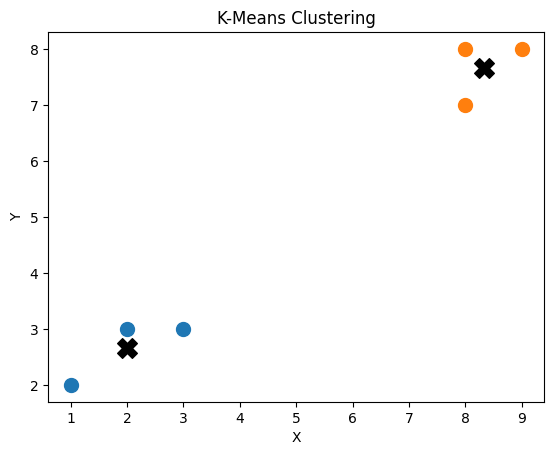

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = [
    [1, 2],
    [2, 3],
    [3, 3],
    [8, 7],
    [8, 8],
    [9, 8]
]

kmeans = KMeans(n_clusters=2, random_state=42)

kmeans.fit(X)

labels = kmeans.labels_

centers = kmeans.cluster_centers_

print("Cluster Labels:", labels)
print("Cluster Centers:")
print(centers)

for i in range(len(X)):
    plt.scatter(X[i][0], X[i][1], c=f"C{labels[i]}", s=100)

plt.scatter(centers[:, 0], centers[:, 1],
            color="black", marker="X", s=200)

plt.title("K-Means Clustering")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

 DBSCAN


Cluster Labels: [ 0  0  0  1  1 -1]
Customer 1: [22, 25000] -> Cluster 0
Customer 2: [25, 27000] -> Cluster 0
Customer 3: [23, 26000] -> Cluster 0
Customer 4: [45, 80000] -> Cluster 1
Customer 5: [47, 85000] -> Cluster 1
Customer 6: [60, 150000] -> Outlier


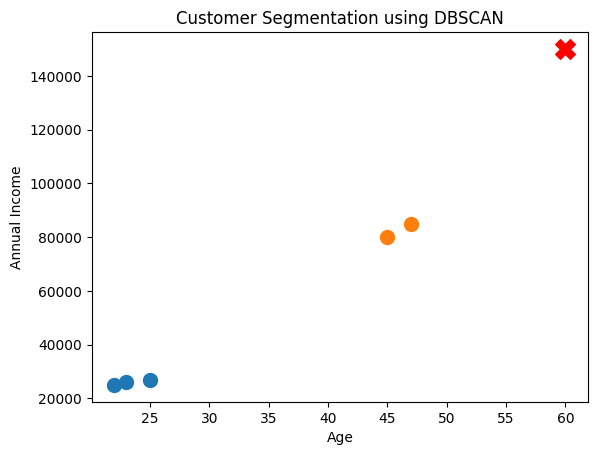

In [4]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Customer data
# [Age, Annual Income]
customers = [
    [22, 25000],
    [25, 27000],
    [23, 26000],
    [45, 80000],
    [47, 85000],
    [60, 150000]
]

dbscan = DBSCAN(eps=10000, min_samples=2)

labels = dbscan.fit_predict(customers)

print("Cluster Labels:", labels)

for i in range(len(customers)):
    if labels[i] == -1:
        print(f"Customer {i+1}: {customers[i]} -> Outlier")
    else:
        print(f"Customer {i+1}: {customers[i]} -> Cluster {labels[i]}")

for i in range(len(customers)):
    if labels[i] == -1:
        plt.scatter(customers[i][0], customers[i][1],
                    color='red', marker='X', s=200)
    else:
        plt.scatter(customers[i][0], customers[i][1],
                    c=f"C{labels[i]}", s=100)

plt.xlabel("Age")
plt.ylabel("Annual Income")
plt.title("Customer Segmentation using DBSCAN")
plt.show()

Assiciation Rule

In [5]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Medicine transactions
transactions = [
    ['Paracetamol', 'Vitamin C'],
    ['Paracetamol', 'Cough Syrup'],
    ['Vitamin C', 'Cough Syrup'],
    ['Paracetamol', 'Vitamin C', 'Cough Syrup'],
    ['Paracetamol', 'Vitamin C']
]

# Convert into one-hot encoded DataFrame
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

print(df)

# Find frequent itemsets
frequent_itemsets = apriori(df, min_support=0.4, use_colnames=True)

print("\nFrequent Itemsets")
print(frequent_itemsets)

# Generate association rules
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6
)

print("\nAssociation Rules")
print(rules[['antecedents', 'consequents',
             'support', 'confidence', 'lift']])

   Cough Syrup  Paracetamol  Vitamin C
0        False         True       True
1         True         True      False
2         True        False       True
3         True         True       True
4        False         True       True

Frequent Itemsets
   support                    itemsets
0      0.6               (Cough Syrup)
1      0.8               (Paracetamol)
2      0.8                 (Vitamin C)
3      0.4  (Cough Syrup, Paracetamol)
4      0.4    (Cough Syrup, Vitamin C)
5      0.6    (Vitamin C, Paracetamol)

Association Rules
     antecedents    consequents  support  confidence      lift
0  (Cough Syrup)  (Paracetamol)      0.4    0.666667  0.833333
1  (Cough Syrup)    (Vitamin C)      0.4    0.666667  0.833333
2    (Vitamin C)  (Paracetamol)      0.6    0.750000  0.937500
3  (Paracetamol)    (Vitamin C)      0.6    0.750000  0.937500


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Dimensionality Reduction

In [6]:
import pandas as pd
from sklearn.decomposition import PCA

# Student dataset
data = {
    'Math': [90, 78, 65, 95, 55],
    'Science': [88, 80, 68, 94, 60],
    'English': [85, 76, 70, 92, 58],
    'Social': [86, 79, 67, 93, 57],
    'Computer': [95, 82, 72, 98, 62],
    'Attendance': [92, 85, 80, 96, 75]
}

df = pd.DataFrame(data)

print("Original Data")
print(df)

# Apply PCA
pca = PCA(n_components=2)

reduced_data = pca.fit_transform(df)

print("\nReduced Dataset")
print(reduced_data)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Original Data
   Math  Science  English  Social  Computer  Attendance
0    90       88       85      86        95          92
1    78       80       76      79        82          85
2    65       68       70      67        72          80
3    95       94       92      93        98          96
4    55       60       58      57        62          75

Reduced Dataset
[[ 25.64142224  -1.81573866]
 [  2.47488057  -0.86649989]
 [-21.95524742   2.36355906]
 [ 38.56897341   1.37876408]
 [-44.73002879  -1.06008459]]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Anomaly Detection

In [7]:
from sklearn.ensemble import IsolationForest
import pandas as pd

# Transaction amounts
data = {'Amount': [500, 700, 600, 550, 15000]}
df = pd.DataFrame(data)

# Train Isolation Forest
model = IsolationForest(contamination=0.2, random_state=42)

df['Prediction'] = model.fit_predict(df)

print(df)

# Convert predictions
df['Result'] = df['Prediction'].map({1: 'Normal', -1: 'Anomaly'})
print(df[['Amount', 'Result']])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

   Amount  Prediction
0     500           1
1     700           1
2     600           1
3     550           1
4   15000          -1
   Amount   Result
0     500   Normal
1     700   Normal
2     600   Normal
3     550   Normal
4   15000  Anomaly


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag